In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [39]:
BASE_DIR = os.getcwd()
# DATA_PATH = os.path.join(BASE_DIR, ".", "data", "prepared", "data_diagnostic.csv")

DATA_PATH = "../Predictive_analystics/data/prepared/dataset_diagnostic.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (31726, 25)


,order_id,customer_id,customer_sk,order_placement_date,on_time,in_full,otif,run_id,order_qty,delivered_qty,...,customer_name,city,planned_lead_days,actual_lead_days,delay_days,delivery_rate,revenue_diff,order_month,order_weekday,is_weekend
0,FAP416403403,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-04-15,1,0,0,manual__2026-03-24T16:18:57.462115+00:00,1712,1659,...,Propel Mart,Vadodara,1,1,0,0.969042,-7025000,4,4,0
1,FAP429403402,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-04-27,1,0,0,manual__2026-03-24T16:18:57.462115+00:00,844,821,...,Propel Mart,Vadodara,2,2,0,0.972749,-2001000,4,2,0
2,FAP430403402,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-04-27,1,0,0,manual__2026-03-24T16:18:57.462115+00:00,891,842,...,Propel Mart,Vadodara,3,3,0,0.945006,-3234000,4,2,0
3,FAUG824403503,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-08-22,1,0,0,manual__2026-03-24T16:18:57.462115+00:00,1593,1569,...,Propel Mart,Vadodara,2,2,0,0.984934,-3480000,8,0,0
4,FAUG85403603,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-08-04,1,0,0,manual__2026-03-24T16:18:57.462115+00:00,842,829,...,Propel Mart,Vadodara,1,1,0,0.984561,-403000,8,3,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31726 entries, 0 to 31725
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              31726 non-null  object 
 1   customer_id           31726 non-null  int64  
 2   customer_sk           31726 non-null  object 
 3   order_placement_date  31726 non-null  object 
 4   on_time               31726 non-null  int64  
 5   in_full               31726 non-null  int64  
 6   otif                  31726 non-null  int64  
 7   run_id                31726 non-null  object 
 8   order_qty             31726 non-null  int64  
 9   delivered_qty         31726 non-null  int64  
 10  actual_revenue        31726 non-null  int64  
 11  expected_revenue      31726 non-null  int64  
 12  expense               31726 non-null  int64  
 13  agreed_delivery_date  31726 non-null  object 
 14  actual_delivery_date  31726 non-null  object 
 15  customer_name      

In [41]:
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ["column", "missing_count"]
missing_df["missing_percent"] = (missing_df["missing_count"] / len(df)) * 100
missing_df.sort_values("missing_count", ascending=False)

,column,missing_count,missing_percent
0,order_id,0,0.0
1,customer_id,0,0.0
2,customer_sk,0,0.0
3,order_placement_date,0,0.0
4,on_time,0,0.0
5,in_full,0,0.0
6,otif,0,0.0
7,run_id,0,0.0
8,order_qty,0,0.0
9,delivered_qty,0,0.0


In [42]:
df.describe()

,customer_id,on_time,in_full,otif,order_qty,delivered_qty,actual_revenue,expected_revenue,expense,planned_lead_days,actual_lead_days,delay_days,delivery_rate,revenue_diff,order_month,order_weekday,is_weekend
count,31726.000000,31726.000000,31726.000000,31726.000000,31726.000000,31726.000000,3.172600e+04,3.172600e+04,3.172600e+04,31726.000000,31726.000000,31726.000000,31726.000000,3.172600e+04,31726.000000,31726.000000,31726.000000
mean,789423.591124,0.590304,0.527832,0.290235,423.133203,408.706802,3.687021e+07,3.816506e+07,2.941320e+07,1.998203,2.593709,0.595505,0.965135,-1.294849e+06,5.476833,3.005800,0.288880
std,219.092415,0.491785,0.499233,0.453878,324.715133,314.879634,3.358449e+07,3.463728e+07,2.670392e+07,0.814659,1.364008,1.093719,0.051898,2.541828e+06,1.704123,2.005469,0.453249
min,789101.000000,0.000000,0.000000,0.000000,20.000000,16.000000,6.970000e+05,8.500000e+05,4.510000e+05,1.000000,0.000000,-1.000000,0.782608,-3.063200e+07,3.000000,0.000000,0.000000
25%,789220.000000,0.000000,0.000000,0.000000,177.000000,170.000000,8.690000e+06,9.042000e+06,7.070500e+06,1.000000,2.000000,0.000000,0.948837,-1.452000e+06,4.000000,1.000000,0.000000
50%,789420.000000,1.000000,1.000000,0.000000,360.000000,346.000000,2.844150e+07,2.956800e+07,2.308500e+07,2.000000,3.000000,0.000000,1.000000,0.000000e+00,5.000000,3.000000,0.000000
75%,789601.000000,1.000000,1.000000,1.000000,558.000000,539.000000,5.493400e+07,5.684000e+07,4.375800e+07,3.000000,3.000000,1.000000,1.000000,0.000000e+00,7.000000,5.000000,1.000000
max,789903.000000,1.000000,1.000000,1.000000,2403.000000,2346.000000,2.305320e+08,2.388340e+08,1.838350e+08,3.000000,6.000000,3.000000,1.000000,0.000000e+00,8.000000,6.000000,1.000000


In [ ]:


df["order_placement_date"] = pd.to_datetime(df["order_placement_date"], errors="coerce")
df["agreed_delivery_date"] = pd.to_datetime(df["agreed_delivery_date"], errors="coerce")
df["actual_delivery_date"] = pd.to_datetime(df["actual_delivery_date"], errors="coerce")

# Feature engineering
df["planned_lead_days"] = (df["agreed_delivery_date"] - df["order_placement_date"]).dt.days
df["actual_lead_days"] = (df["actual_delivery_date"] - df["order_placement_date"]).dt.days
df["delay_days"] = df["actual_lead_days"] - df["planned_lead_days"]

# Check abnormal planned lead time
abnormal_planned = df[df["planned_lead_days"] < 0]
print("Abnormal planned lead records:", abnormal_planned.shape[0])

abnormal_planned[[
    "order_id", "order_placement_date", "agreed_delivery_date", "planned_lead_days"
]].head(10)

Abnormal planned lead records: 0


,order_id,order_placement_date,agreed_delivery_date,planned_lead_days


In [44]:
df["profit"] = df["actual_revenue"] - df["expense"]

## Overview

In [45]:
performance_summary = pd.DataFrame({
    "Metric": ["On-Time Rate", "In-Full Rate", "OTIF Rate"],
    "Rate": [
        df["on_time"].mean(),
        df["in_full"].mean(),
        df["otif"].mean()
    ]
})

performance_summary

,Metric,Rate
0,On-Time Rate,0.590304
1,In-Full Rate,0.527832
2,OTIF Rate,0.290235


 
 Timming và fullfilment đều kém

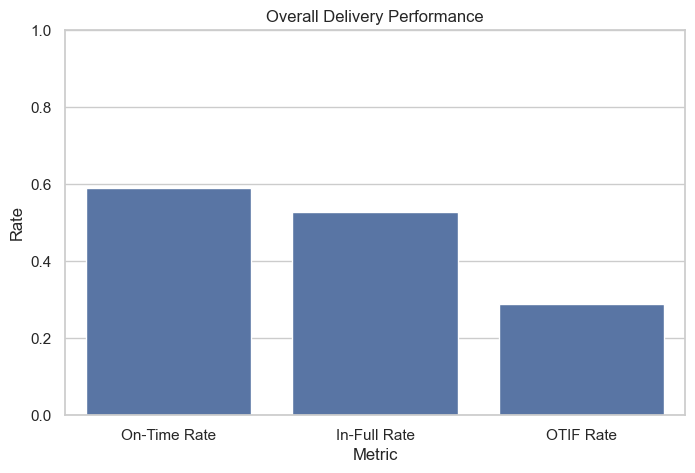

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(data=performance_summary, x="Metric", y="Rate")
plt.title("Overall Delivery Performance")
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.show()

## Cause

### CUSTOMER (NAME,CITY) => ISSUE_TYPE

In [82]:

customer_perf = df.groupby(["customer_id", "customer_name", "city"]).agg({
    "on_time": "mean",
    "in_full": "mean",
    "otif": "mean",
    "order_id": "count"
}).reset_index()

customer_perf.columns = [
    "customer_id", "customer_name", "city",
    "on_time_rate", "in_full_rate", "otif_rate", "total_orders"
]

customer_perf

,customer_id,customer_name,city,on_time_rate,in_full_rate,otif_rate,total_orders
0,789101,Vijay Stores,Surat,0.725610,0.584146,0.381707,820
1,789102,Vijay Stores,Ahmedabad,0.697954,0.583634,0.359807,831
2,789103,Vijay Stores,Vadodara,0.749693,0.179141,0.105521,815
3,789121,Coolblue,Ahmedabad,0.296388,0.671593,0.203612,1218
4,789122,Coolblue,Vadodara,0.286535,0.222496,0.071429,1218
5,789201,Rel Fresh,Surat,0.725765,0.568878,0.371173,784
6,789202,Rel Fresh,Ahmedabad,0.730724,0.606168,0.403321,843
7,789203,Rel Fresh,Vadodara,0.713253,0.584337,0.369880,830
8,789220,Atlas Stores,Surat,0.723404,0.595745,0.397997,799
9,789221,Atlas Stores,Ahmedabad,0.713105,0.599764,0.393152,847


### issue_type

In [48]:
on_time_threshold = customer_perf["on_time_rate"].quantile(0.4)
in_full_threshold = customer_perf["in_full_rate"].quantile(0.4)

# Lấy vị trí 40% (vd {2,3,4,5,6,7} có 6 số z thứ tự vị trí là 2.4 nên quantile(0.4) xấp xĩ 4.4 cỡ đóo) tại đó là ngưỡng rồi dưới đó sẽ là thấp , trên sẽ cao

def classify_issue(row):
    if row["on_time_rate"] < on_time_threshold and row["in_full_rate"] < in_full_threshold:
        return "Late and Short Delivery"
    elif row["on_time_rate"] >= on_time_threshold and row["in_full_rate"] < in_full_threshold:
        return "Short Delivery"
    elif row["on_time_rate"] < on_time_threshold and row["in_full_rate"] >= in_full_threshold:
        return "Late Delivery"
    else:
        return "Stable"

customer_perf["issue_type"] = customer_perf.apply(classify_issue, axis=1)
customer_perf[["customer_name","city","on_time_rate","in_full_rate","otif_rate","issue_type"]].sort_values("otif_rate").head(15)

customer_perf.head()

,customer_id,customer_name,city,on_time_rate,in_full_rate,otif_rate,total_orders,issue_type
0,789101,Vijay Stores,Surat,0.725610,0.584146,0.381707,820,Short Delivery
1,789102,Vijay Stores,Ahmedabad,0.697954,0.583634,0.359807,831,Late and Short Delivery
2,789103,Vijay Stores,Vadodara,0.749693,0.179141,0.105521,815,Short Delivery
3,789121,Coolblue,Ahmedabad,0.296388,0.671593,0.203612,1218,Late Delivery
4,789122,Coolblue,Vadodara,0.286535,0.222496,0.071429,1218,Late and Short Delivery


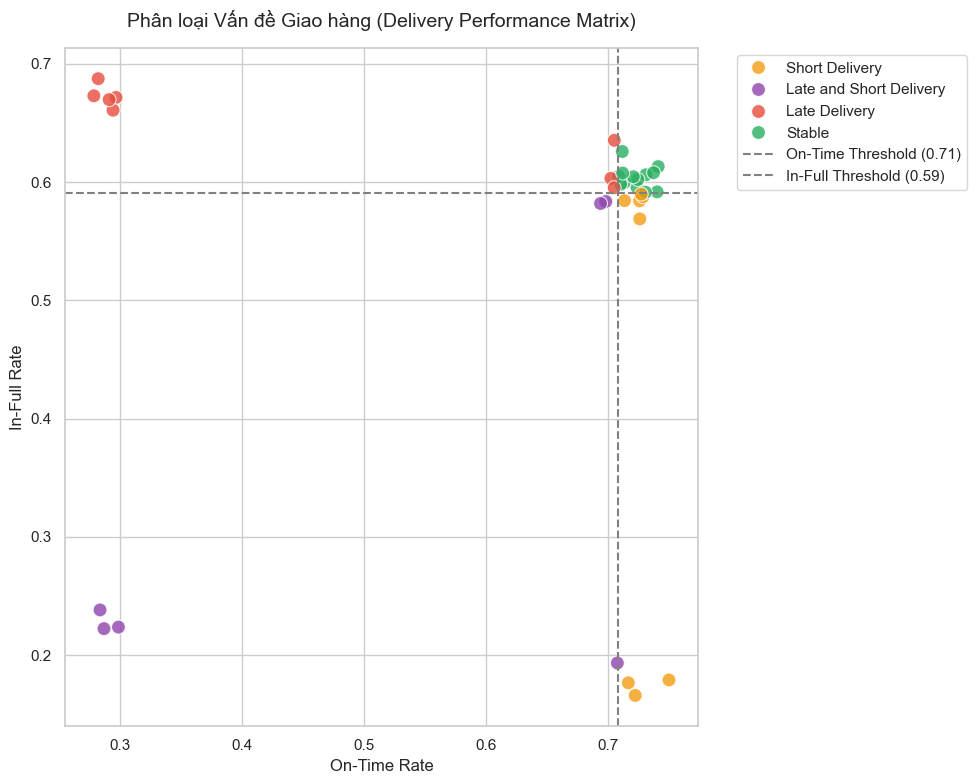

In [ ]:
plt.figure(figsize=(10, 8))

color_dict = {
    "Stable": "#27ae60",                
    "Late Delivery": "#e74c3c",          
    "Short Delivery": "#f39c12",         
    "Late and Short Delivery": "#8e44ad" 
}

sns.scatterplot(
    data=customer_perf,
    x="on_time_rate",
    y="in_full_rate",
    hue="issue_type",
    palette=color_dict,
    s=100, 
    alpha=0.8
)
plt.axvline(x=on_time_threshold, color='grey', linestyle='--', label=f'On-Time Threshold ({on_time_threshold:.2f})')
plt.axhline(y=in_full_threshold, color='grey', linestyle='--', label=f'In-Full Threshold ({in_full_threshold:.2f})')

plt.title("Phân loại Vấn đề Giao hàng (Delivery Performance Matrix)", fontsize=14, pad=15)
plt.xlabel("On-Time Rate", fontsize=12)
plt.ylabel("In-Full Rate", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [50]:
## Ưu tiên xử lí issue nào trc ở mỗi City

In [51]:
city_issue_summary = pd.crosstab(customer_perf['city'], customer_perf['issue_type'])


if "Late and Short Delivery" in city_issue_summary.columns:
    city_issue_summary = city_issue_summary.sort_values(by="Late and Short Delivery", ascending=False)

city_issue_summary

issue_type,Late Delivery,Late and Short Delivery,Short Delivery,Stable
city,,,,
Surat,2,3,3,3
Ahmedabad,2,2,2,6
Vadodara,4,1,3,4


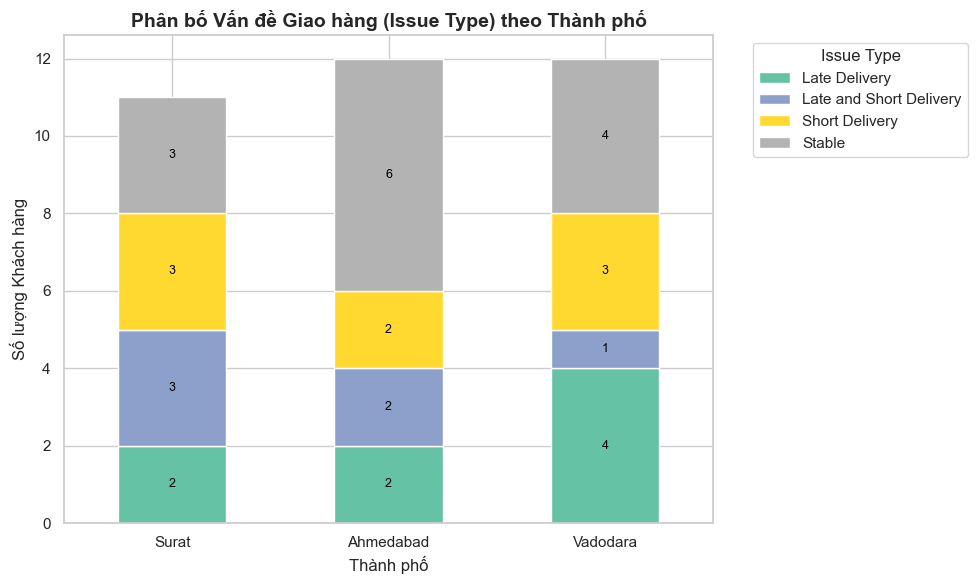

In [ ]:

sns.set_theme(style="whitegrid")

ax = city_issue_summary.plot(
    kind='bar',
    stacked=True,
    colormap='Set2',
    figsize=(10, 6)
)

# Tiêu đề và nhãn
plt.title("Phân bố Vấn đề Giao hàng (Issue Type) theo Thành phố", fontsize=14, fontweight='bold')
plt.xlabel("Thành phố", fontsize=12)
plt.ylabel("Số lượng Khách hàng", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Issue Type", bbox_to_anchor=(1.05, 1), loc='upper left')


for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',   
        fontsize=9,
        color='black'
    )

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

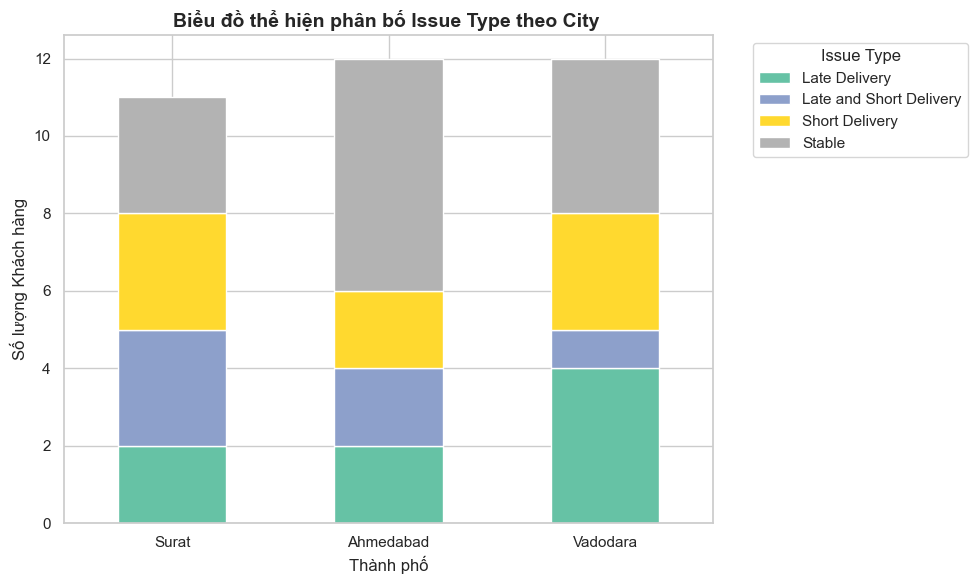

In [80]:
sns.set_theme(style="whitegrid")

# City vs Issue Type (Ưu tiên xử lý issue ở mỗi City)
plt.figure(figsize=(10, 6))
city_issue_summary.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 6))

plt.title("Biểu đồ thể hiện phân bố Issue Type theo City ", fontsize=14, fontweight='bold')
plt.xlabel("Thành phố", fontsize=12)
plt.ylabel("Số lượng Khách hàng", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Issue Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

* Surat: Ưu tiên Short
* Ahmedabad: Nhân rộng quy trình của 6 cửa hàng stable
* Vadodara: Ưu tiên Late

In [53]:
df = df.merge(
    customer_perf[["customer_id", "city", "issue_type"]],
    on=["customer_id", "city"],
    how="left"
)

In [54]:
df.groupby("issue_type")["profit"].mean()

issue_type
Late Delivery              6.435285e+06
Late and Short Delivery    6.564198e+06
Short Delivery             8.290184e+06
Stable                     8.256606e+06
Name: profit, dtype: float64

In [55]:
## Mức chênh lệch doanh thu
df.groupby("issue_type")["revenue_diff"].mean()

issue_type
Late Delivery             -8.376384e+05
Late and Short Delivery   -1.912642e+06
Short Delivery            -1.790130e+06
Stable                    -1.006700e+06
Name: revenue_diff, dtype: float64

C:\Users\ACER\AppData\Local\Temp\ipykernel_10656\1252928197.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=issue_profit, x="issue_type", y="profit", palette="muted")


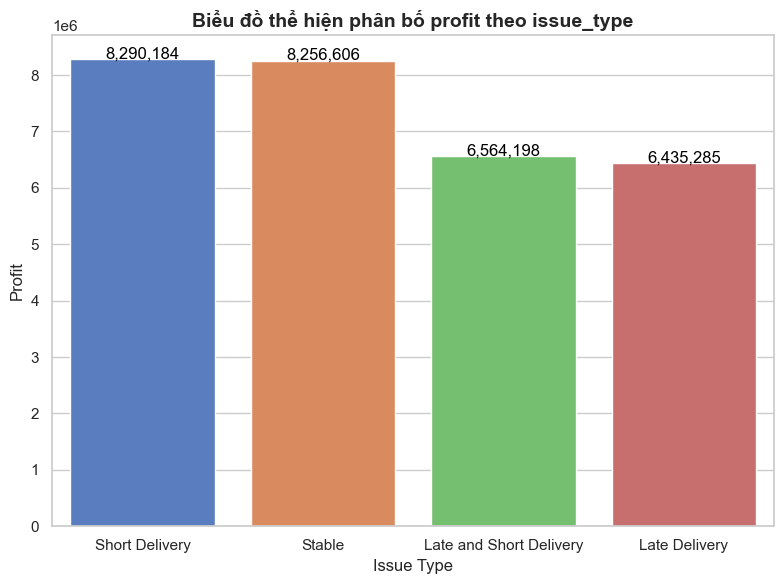

In [81]:

# 2. Tác động của Issue Type đến Lợi nhuận
plt.figure(figsize=(8, 6))
issue_profit = df.groupby("issue_type")["profit"].mean().reset_index()
# Sắp xếp theo profit giảm dần để biểu đồ có tính thứ bậc
issue_profit = issue_profit.sort_values("profit", ascending=False)

sns.barplot(data=issue_profit, x="issue_type", y="profit", palette="muted")
plt.title("Biểu đồ thể hiện phân bố profit theo issue_type", fontsize=14, fontweight='bold')
plt.xlabel("Issue Type", fontsize=12)
plt.ylabel("Profit", fontsize=12)
# Thêm số liệu lên đầu cột
for index, row in enumerate(issue_profit["profit"]):
    plt.text(index, row + 10000, f"{row:,.0f}", color='black', ha="center")
plt.tight_layout()
plt.show()


Nhóm Short Delivery và Stable có lợi nhuận trung bình cao nhất (~8.25–8.29 triệu)
Trong khi đó, các nhóm có vấn đề liên quan đến giao trễ:
Late Delivery (~6.43 triệu)
Late and Short Delivery (~6.56 triệu)
có lợi nhuận thấp hơn đáng kể

Điều này cho thấy:

Giao trễ (Late Delivery) có tác động tiêu cực rõ rệt đến lợi nhuận

Ngay cả khi chỉ trễ (không thiếu hàng), profit vẫn giảm đáng kể

> Insight chính
Các đơn hàng bị delay thường mang lại lợi nhuận thấp hơn
Trong khi đó, Short Delivery vẫn có thể giữ được lợi nhuận cao hơn do vẫn đảm bảo tiến độ giao hàng

### Order_size

In [57]:
##quantile-based segmentation

df["order_size_group"] = pd.qcut(
    df["order_qty"],
    q=4,
    labels=["Small", "Medium", "Large", "Very Large"]
)

df["order_size_group"].value_counts()


order_size_group
Small         7972
Large         7924
Very Large    7920
Medium        7910
Name: count, dtype: int64

In [58]:
order_size_perf = df.groupby("order_size_group").agg({
    "on_time": "mean",
    "in_full": "mean",
    "otif": "mean",
    "order_id": "count"
}).reset_index()
order_size_perf

C:\Users\ACER\AppData\Local\Temp\ipykernel_10656\382467282.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_size_perf = df.groupby("order_size_group").agg({


,order_size_group,on_time,in_full,otif,order_id
0,Small,0.430883,0.636979,0.277095,7972
1,Medium,0.507459,0.588496,0.293426,7910
2,Large,0.566507,0.545432,0.298460,7924
3,Very Large,0.857323,0.339773,0.292045,7920


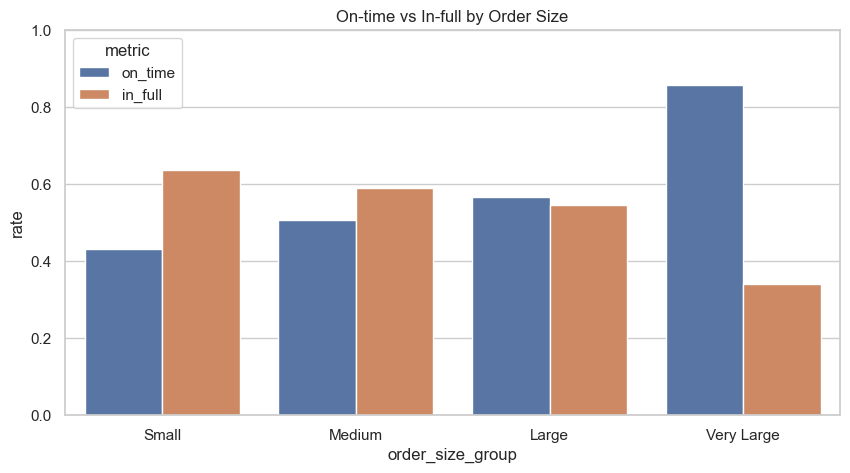

In [59]:
order_size_perf_melt = order_size_perf.melt(
    id_vars="order_size_group",
    value_vars=["on_time", "in_full"],
    var_name="metric",
    value_name="rate"
)

plt.figure(figsize=(10,5))
sns.barplot(data=order_size_perf_melt, x="order_size_group", y="rate", hue="metric")
plt.title("On-time vs In-full by Order Size")
plt.ylim(0,1)
plt.show()

Phân tích theo quy mô đơn hàng cho thấy hiệu suất giao hàng có sự khác biệt rõ rệt giữa các nhóm:

* Nhóm Very Large có tỷ lệ on-time rất cao (0.8573), tuy nhiên in-full lại rất thấp (0.3398)

* Ngược lại, nhóm Small có in-full cao hơn (0.6370) nhưng on-time thấp (0.4309)

=>Điều này cho thấy tồn tại sự đánh đổi giữa giao đúng hạn và giao đủ hàng:

* Đơn hàng lớn thường được ưu tiên về thời gian giao → giao đúng hạn cao

* Tuy nhiên, việc đảm bảo đủ số lượng trở nên khó khăn → dẫn đến thiếu hàng

Trong khi đó, đơn hàng nhỏ dễ đáp ứng đủ hàng hơn nhưng lại ít được ưu tiên về thời gian → dẫn đến giao trễ nhiều hơn

**Kết luận**

Đơn lớn → mạnh về on-time, yếu về in-full

Đơn nhỏ → mạnh về in-full, yếu về on-time

>→ Điều này cho thấy cần cân bằng giữa tốc độ giao hàng và khả năng đáp ứng đơn hàng, đặc biệt đối với các đơn hàng có quy mô lớn.

### Bussiness impact

In [60]:
df["profit"].describe()

count    3.172600e+04
mean     7.457010e+06
std      7.050290e+06
min      1.680000e+05
25%      1.729000e+06
50%      5.447000e+06
75%      1.117475e+07
max      4.771000e+07
Name: profit, dtype: float64

In [61]:
impact_on_time = df.groupby("on_time").agg({
    "actual_revenue": ["mean", "sum"],
    "expected_revenue": ["mean", "sum"],
    "revenue_diff": ["mean", "sum"],
    "profit": ["mean", "sum"],
    "order_id": "count"
}).reset_index()
impact_on_time


on_time actual_revenue               expected_revenue                \
                    mean           sum             mean           sum   
0       0   2.577697e+07  335048998000     2.679898e+07  348333119000   
1       1   4.456938e+07  834695367000     4.605359e+07  862491618000   

   revenue_diff                     profit               order_id  
           mean          sum          mean           sum    count  
0 -1.022013e+06 -13284121000  5.215997e+06   67797526000    12998  
1 -1.484208e+06 -27796251000  9.012365e+06  168783576000    18728

=> Các đơn hàng được giao đúng hạn (on-time) thường tạo ra doanh thu thực tế (actual revenue) và lợi nhuận (profit) cao hơn trên mỗi đơn hàng. Điều này cho thấy việc giao hàng đúng hạn thường gắn liền với những đơn hàng có giá trị thương mại cao hơn.

In [62]:
impact_in_full = df.groupby("in_full").agg({
    "actual_revenue": ["mean", "sum"],
    "expected_revenue": ["mean", "sum"],
    "revenue_diff": ["mean", "sum"],
    "profit": ["mean", "sum"],
    "order_id": "count"
}).reset_index()
impact_in_full

in_full actual_revenue               expected_revenue                \
                    mean           sum             mean           sum   
0       0   4.254575e+07  637335297000     4.528810e+07  678415669000   
1       1   3.179321e+07  532409068000     3.179321e+07  532409068000   

   revenue_diff                     profit               order_id  
           mean          sum          mean           sum    count  
0 -2.742348e+06 -41080372000  8.606004e+06  128917946000    14980  
1  0.000000e+00            0  6.429186e+06  107663156000    16746

=> Khả năng giao đủ hàng (in-full) có ảnh hưởng trực tiếp đến mức độ hiện thực hóa doanh thu. Cụ thể, những đơn hàng không được giao đủ ghi nhận mức chênh lệch doanh thu âm (revenue_diff) đáng kể, trong khi những đơn hàng được giao đủ có thể đạt đúng mức doanh thu kỳ vọng (expected revenue). Điều này cho thấy fulfillment completeness là một yếu tố tác động mạnh đến **doanh thu**

In [63]:
impact_otif = df.groupby("otif").agg({
    "actual_revenue": ["mean", "sum"],
    "expected_revenue": ["mean", "sum"],
    "revenue_diff": ["mean", "sum"],
    "profit": ["mean", "sum"],
    "order_id": "count"
}).reset_index()
impact_otif

otif actual_revenue               expected_revenue                \
                 mean           sum             mean           sum   
0    0   3.649901e+07  821884720000     3.832335e+07  862965092000   
1    1   3.777798e+07  347859645000     3.777798e+07  347859645000   

   revenue_diff                     profit               order_id  
           mean          sum          mean           sum    count  
0 -1.824335e+06 -41080372000  7.384747e+06  166289728000    22518  
1  0.000000e+00            0  7.633729e+06   70291374000     9208

OTIF có mối liên hệ với hiệu quả kinh doanh tốt hơn. Những đơn hàng vừa đúng hạn vừa đủ hàng có khả năng đạt đúng doanh thu kỳ vọng, trong khi các đơn hàng không đạt OTIF thường đi kèm với mức lợi nhuận thấp hơn và khoản hụt doanh thu đáng kể

In [64]:
df["revenue_loss_rate"] = (df["actual_revenue"] - df["expected_revenue"]) / df["expected_revenue"]

### Temporal

In [65]:
lead_perf = df.groupby("planned_lead_days")["on_time"].mean().reset_index()   ## agrre-order plac: khoảng thời gian công ty cam kết giao hàng
lead_perf.columns = ["planned_lead_days", "on_time_rate"]

lead_perf

,planned_lead_days,on_time_rate
0,1,0.589996
1,2,0.589635
2,3,0.591294


In [66]:
df["delay_days"] = df["actual_lead_days"] - df["planned_lead_days"]

df["delay_days"].describe()

count    31726.000000
mean         0.595505
std          1.093719
min         -1.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: delay_days, dtype: float64

In [67]:
df.groupby("planned_lead_days")["delay_days"].mean()

planned_lead_days
1    0.597006
2    0.591603
3    0.597962
Name: delay_days, dtype: float64

Thời gian trễ trung bình gần như không thay đổi giữa các mức lead time (khoảng ~0.59 ngày). Điều này cho thấy lead time không ảnh hưởng đáng kể đến độ trễ giao hàng.

In [68]:
df["order_month"].unique()

array([4, 8, 6, 3, 7, 5])

In [69]:
month_perf = df.groupby("order_month").agg(
    on_time_rate=("on_time", "mean"),
    in_full_rate=("in_full", "mean"),
    otif_rate=("otif", "mean"),
    total_orders=("order_id", "count")
).reset_index()
month_perf

,order_month,on_time_rate,in_full_rate,otif_rate,total_orders
0,3,0.595819,0.523307,0.288753,5406
1,4,0.593030,0.525805,0.286803,5251
2,5,0.585010,0.536644,0.291305,5417
3,6,0.585076,0.520430,0.287167,5213
4,7,0.593931,0.524817,0.293501,5339
5,8,0.588824,0.536078,0.293922,5100


In [70]:
weekday_perf = df.groupby("order_weekday").agg( 
    on_time_rate=("on_time", "mean"),
    in_full_rate=("in_full", "mean"),
    otif_rate=("otif", "mean"),
    total_orders=("order_id", "count")
).reset_index()


weekday_perf

,order_weekday,on_time_rate,in_full_rate,otif_rate,total_orders
0,0,0.587751,0.535857,0.292873,4490
1,1,0.585097,0.520302,0.280994,4630
2,2,0.590939,0.530313,0.294248,4503
3,3,0.596857,0.520763,0.292929,4455
4,4,0.596476,0.534464,0.295561,4483
5,5,0.590221,0.520281,0.286341,4561
6,6,0.585143,0.533015,0.289096,4604


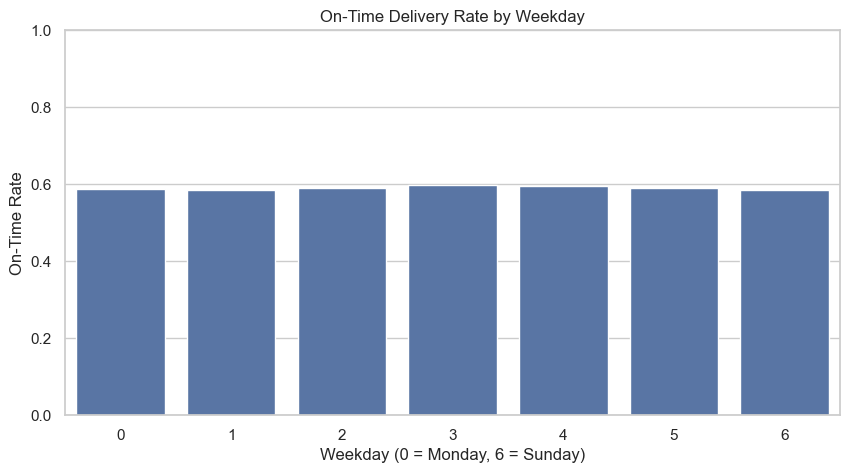

In [71]:
plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_perf, x="order_weekday", y="on_time_rate")
plt.title("On-Time Delivery Rate by Weekday")
plt.xlabel("Weekday (0 = Monday, 6 = Sunday)")
plt.ylabel("On-Time Rate")
plt.ylim(0, 1)
plt.show()

In [72]:
weekend_perf = df.groupby("is_weekend").agg( 
    on_time_rate=("on_time", "mean"),
    in_full_rate=("in_full", "mean"),
    otif_rate=("otif", "mean"),
    total_orders=("order_id", "count")
).reset_index()

weekend_perf

,is_weekend,on_time_rate,in_full_rate,otif_rate,total_orders
0,0,0.591374,0.528301,0.291255,22561
1,1,0.587670,0.526678,0.287725,9165


=> Hiệu suất giao hàng không bị ảnh hưởng mạnh bởi yếu tố thời gian trong tuần.  
Các vấn đề về on-time và OTIF nhiều khả năng xuất phát từ các yếu tố khác như vận hành logistics hoặc khả năng cung ứng, thay vì do lịch làm việc theo ngày.